In dieser Aufgabe sollen v.a. das Magnitudenspektrum sowie Auswirkungen von Bildänderungen auf das Spektrum näher untersucht werden.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import gaussian

Letzte Woche haben wir in der Präsenzübung Sinusoide erzeugt und daraus ein einfaches Bild kreiert, indem wir aus 1D Sinusoiden einen 2D Sinusoid gebaut haben (Bildzeile zu Bild). Diese Woche ist für das Erzeugen eines 2D-Sinusoiden direkt die Funktion ```generate_2d_sine_wave()``` gegeben. Diese wird in folgendem Beispiel genutzt, um das Bild eines 2D-Sinusoids mit Frequenz 10 zu erstellen. Die Schwingung geht dabei im Winkel von $0^\circ$ von oben nach unten im Bild, bildet also waagerechte Streifen.

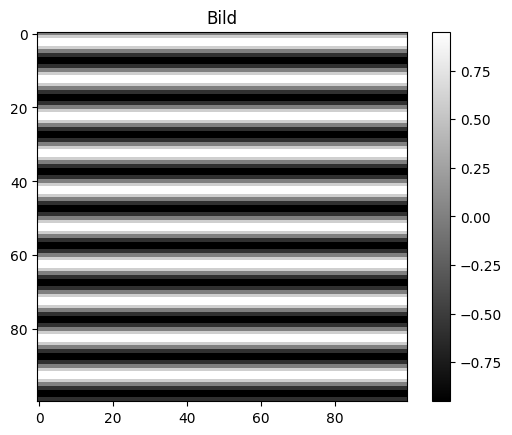

In [2]:
def generate_2d_sine_wave(size=100, frequency=5, angle_deg=0, phase_deg=0, amplitude=1):
    """
    Erzeugt eine 2D-Sinuswelle mit einstellbarer Orientierung, Phase, Winkel und Amplitude.

    Parameters:
    - size: Größe des Bildes (size x size)
    - frequency: Frequenz der Sinuswelle
    - angle_deg: Orientierung der Welle in Grad
    - phase_deg: Phase in Grad
    - amplitude: Amplitude

    Returns:
    - 2D NumPy-Array mit Sinuswelle
    """
    # Raster erstellen
    x = np.arange(size) - size / 2
    y = np.arange(size) - size / 2
    X, Y = np.meshgrid(x, y)

    # Winkel und Phase in Bogenmaß umrechnen
    angle_rad = np.deg2rad(angle_deg)
    phase_rad = np.deg2rad(phase_deg)

    # Richtung der Welle anhand des Winkels definieren
    # Das Skalarprodukt bestimmt die Orientierung
    Z = amplitude * np.sin(
        2 * np.pi * frequency / size * ((X) * np.sin(angle_rad) + Y * np.cos(angle_rad))
        + phase_rad
    )

    return Z


img = generate_2d_sine_wave(
    size=100, frequency=10, angle_deg=0, phase_deg=0, amplitude=1
)

plt.title("Bild")
plt.imshow(img, cmap="gray")
plt.colorbar()
plt.show()

Wendet nun auf dieses Bild die 2D DFT an, zentriert die Fouriertransformierte und extrahiert das Magnitudenspektrum. Zeigt das Spektren an. Warum sieht das Magnitudenspektrum so aus?

Ändert nun den Winkel, nicht die Phase, des Sinusoiden. Wendet wieder die 2D DFT an, zentriert die Fouriertransformierte und extrahiert das Magnitudenspektrum. Welche Änderungen sind zu beobachten?

Ändert nun den Winkel wieder auf $0^\circ$ und setzt die Phase auf $90^\circ$. Welche Auswirkungen hat das auf das Bild und das Magnitudenspektrum?

Nun sollen 180 Sinusoide mit der Frequenz 1 und einer Phase von $90^\circ$ in einem Bild kombiniert werden. Die Sinusoide unterscheiden sich in ihrem Winkel und nehmen dabei die ganzahligen Werte von $-90^\circ$ bis $89^\circ$ an. Welche Auswirkungen hat das auf das Bild und das Magnitudenspektrum?

Erzeugt jetzt ein 256x256 Pixel großes Bild, das komplett schwarz ist. Setzt den Bereich von `100:-100` auf der x-Achse und von `120:-120` auf der y-Achse auf 1. Es sollte ein Rechteck entstehen. Berechnet nun die 2D DFT, zentriert die Fouriertransformierte und extrahiert Magnituden- **und Phasenspektrum**. Wie werden die Spektren aussehen?

Verändern sich die Spektren, wenn das Rechteck um jeweils 50 Pixel nach unten und nach rechts verschoben wird?

Wendet nun auf euer Rechteck zunächst einen Gaußfilter mit $\sigma=7$ an, um die Kanten des Rechtecks weichzuzeichnen. Welche Auswirkungen hat das auf Magnitudenspektrum? Das Pasenspektrum benötigen wir hier nicht mehr.